In [1]:
import pandas as pd

df = pd.read_csv("db.csv", encoding="latin1")

# Filtro geográfico: CDMX y Tlalpan
df_tlalpan = df[
    (df["cve_ent"] == 9) &
    (df["cve_mun"] == 7)
].copy()

# Códigos de atención médica general
codigos_salud_general = [
    621111,
    621112,
    621115,
    621116,
    622111,
    622112
]

df_salud_general = df_tlalpan[
    df_tlalpan["codigo_act"].isin(codigos_salud_general)
].copy()

# Revisar conteo por actividad
conteo = (
    df_salud_general
    .groupby(["codigo_act", "nombre_act"])
    .size()
    .reset_index(name="n")
    .sort_values("codigo_act")
)

print(conteo)
print("Total:", len(df_salud_general))

   codigo_act                                         nombre_act    n
0      621111  Consultorios de medicina general del sector pr...  448
1      621112  Consultorios de medicina general del sector pú...   16
2      621115  Clínicas de consultorios médicos del sector pr...   28
3      621116  Clínicas de consultorios médicos del sector pú...   37
4      622111            Hospitales generales del sector privado   16
5      622112            Hospitales generales del sector público   18
Total: 563


In [2]:
df_salud_general.to_csv("salud_general_iztapalapa.csv", index=False, encoding="latin1")

In [3]:
# ============================================================================
# ANÁLISIS DESCRIPTIVO Y ESPACIAL DE ESTABLECIMIENTOS DE SALUD EN TLALPAN
# ============================================================================
# Este script genera visualizaciones para análisis previo a persistencia homológica
# 
# Librerías requeridas:
# pip install pandas matplotlib seaborn scikit-learn numpy
# ============================================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.neighbors import BallTree
import os
from pathlib import Path

# Configurar estilo
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 10

# ============================================================================
# 1. CARGA DE DATOS
# ============================================================================
print("=" * 70)
print("PASO 1: CARGA DE DATOS")
print("=" * 70)

# Leer el CSV
df = pd.read_csv("salud_general_iztapalapa.csv", encoding="latin1")

print(f"✓ CSV cargado exitosamente")
print(f"  Dimensiones: {df.shape[0]} filas × {df.shape[1]} columnas")
print(f"\n  Columnas disponibles:")
print(f"  {list(df.columns)}")
print(f"\n  Primeras filas:")
print(df.head())
print(f"\n  Tipos de datos:")
print(df.dtypes)


PASO 1: CARGA DE DATOS
✓ CSV cargado exitosamente
  Dimensiones: 563 filas × 42 columnas

  Columnas disponibles:
  ['id', 'clee', 'nom_estab', 'raz_social', 'codigo_act', 'nombre_act', 'per_ocu', 'tipo_vial', 'nom_vial', 'tipo_v_e_1', 'nom_v_e_1', 'tipo_v_e_2', 'nom_v_e_2', 'tipo_v_e_3', 'nom_v_e_3', 'numero_ext', 'letra_ext', 'edificio', 'edificio_e', 'numero_int', 'letra_int', 'tipo_asent', 'nomb_asent', 'tipoCenCom', 'nom_CenCom', 'num_local', 'cod_postal', 'cve_ent', 'entidad', 'cve_mun', 'municipio', 'cve_loc', 'localidad', 'ageb', 'manzana', 'telefono', 'correoelec', 'www', 'tipoUniEco', 'latitud', 'longitud', 'fecha_alta']

  Primeras filas:
         id                          clee  \
0   9468851  09007622111000313000000000U6   
1    656726  09007621111004641000000000U7   
2  11160745  09007621111010351000000000U5   
3    838240  09007621111005192000000000U0   
4    842080  09007622311000011000000000U2   

                                          nom_estab               raz_s

In [4]:
# ============================================================================
# 2. LIMPIEZA BÁSICA
# ============================================================================
print("\n" + "=" * 70)
print("PASO 2: LIMPIEZA BÁSICA")
print("=" * 70)

# Revisar valores faltantes antes de limpieza
print(f"\nValores faltantes antes de limpieza:")
print(df.isnull().sum())

# Eliminar registros sin latitud o longitud
df_clean = df.dropna(subset=['latitud', 'longitud']).copy()
print(f"\n✓ Registros sin latitud/longitud eliminados")
print(f"  Registros removidos: {df.shape[0] - df_clean.shape[0]}")
print(f"  Registros restantes: {df_clean.shape[0]}")

# Convertir latitud y longitud a numérico
df_clean['latitud'] = pd.to_numeric(df_clean['latitud'], errors='coerce')
df_clean['longitud'] = pd.to_numeric(df_clean['longitud'], errors='coerce')

# Eliminar si hay algún valor NaN después de conversión
df_clean = df_clean.dropna(subset=['latitud', 'longitud'])
print(f"✓ Latitud y longitud convertidas a numérico")
print(f"  Registros finales después de conversión: {df_clean.shape[0]}")

# Revisar rango de coordenadas
print(f"\n  Rango de latitudes: {df_clean['latitud'].min():.6f} a {df_clean['latitud'].max():.6f}")
print(f"  Rango de longitudes: {df_clean['longitud'].min():.6f} a {df_clean['longitud'].max():.6f}")

df = df_clean.copy()


PASO 2: LIMPIEZA BÁSICA

Valores faltantes antes de limpieza:
id              0
clee            0
nom_estab       0
raz_social    452
codigo_act      0
nombre_act      0
per_ocu         0
tipo_vial       0
nom_vial        0
tipo_v_e_1      0
nom_v_e_1       0
tipo_v_e_2      0
nom_v_e_2       0
tipo_v_e_3      0
nom_v_e_3       0
numero_ext     37
letra_ext     263
edificio      544
edificio_e    544
numero_int    295
letra_int     523
tipo_asent      0
nomb_asent      0
tipoCenCom    556
nom_CenCom    555
num_local     555
cod_postal      1
cve_ent         0
entidad         0
cve_mun         0
municipio       0
cve_loc         0
localidad       0
ageb            0
manzana         0
telefono      330
correoelec    453
www           544
tipoUniEco      0
latitud         0
longitud        0
fecha_alta      0
dtype: int64

✓ Registros sin latitud/longitud eliminados
  Registros removidos: 0
  Registros restantes: 563
✓ Latitud y longitud convertidas a numérico
  Registros finales después

In [5]:
# ============================================================================
# 3. CREACIÓN DE VARIABLES DERIVADAS
# ============================================================================
print("\n" + "=" * 70)
print("PASO 3: CREACIÓN DE VARIABLES DERIVADAS")
print("=" * 70)

# 3.1 Crear columna de sector (Privado/Público)
codigos_privado = [621111, 621115, 622111]
codigos_publico = [621112, 621116, 622112]

df['sector'] = df['codigo_act'].apply(
    lambda x: 'Privado' if x in codigos_privado else 'Público'
)
print(f"\n✓ Columna 'sector' creada")
print(df['sector'].value_counts())

# 3.2 Crear columna de tipo de establecimiento
tipo_map = {
    621111: 'Consultorio general privado',
    621112: 'Consultorio general público',
    621115: 'Clínica privada',
    621116: 'Clínica pública',
    622111: 'Hospital general privado',
    622112: 'Hospital general público'
}

df['tipo_establecimiento'] = df['codigo_act'].map(tipo_map)
print(f"\n✓ Columna 'tipo_establecimiento' creada")
print(df['tipo_establecimiento'].value_counts())

# Revisar si hay valores nulos en per_ocu y crear orden lógico
print(f"\n✓ Revisión de 'per_ocu':")
print(f"  Valores únicos: {sorted(df['per_ocu'].unique())}")
print(f"  Conteo:")
print(df['per_ocu'].value_counts().sort_index())

# Definir orden lógico de per_ocu para visualizaciones
orden_per_ocu = [
    "0 a 5 personas",
    "6 a 10 personas",
    "11 a 30 personas",
    "31 a 50 personas",
    "51 a 100 personas",
    "101 a 250 personas",
    "251 y más personas"
]

# Crear categoría ordenada
df['per_ocu'] = pd.Categorical(
    df['per_ocu'],
    categories=orden_per_ocu,
    ordered=True
)

print(f"\n✓ Columna 'per_ocu' convertida a categoría ordenada")



PASO 3: CREACIÓN DE VARIABLES DERIVADAS

✓ Columna 'sector' creada
sector
Privado    492
Público     71
Name: count, dtype: int64

✓ Columna 'tipo_establecimiento' creada
tipo_establecimiento
Consultorio general privado    448
Clínica pública                 37
Clínica privada                 28
Hospital general público        18
Hospital general privado        16
Consultorio general público     16
Name: count, dtype: int64

✓ Revisión de 'per_ocu':
  Valores únicos: ['0 a 5 personas', '101 a 250 personas', '11 a 30 personas', '251 y más personas', '31 a 50 personas', '51 a 100 personas', '6 a 10 personas']
  Conteo:
per_ocu
0 a 5 personas        456
101 a 250 personas     11
11 a 30 personas       28
251 y más personas     11
31 a 50 personas        9
51 a 100 personas      14
6 a 10 personas        34
Name: count, dtype: int64

✓ Columna 'per_ocu' convertida a categoría ordenada


In [6]:
# ============================================================================
# 4. CREAR CARPETA DE SALIDA
# ============================================================================
print("\n" + "=" * 70)
print("PASO 4: CREAR CARPETA DE SALIDA")
print("=" * 70)

# Crear carpetas si no existen
output_dir = Path("outputs")
figures_dir = output_dir / "figures"

output_dir.mkdir(exist_ok=True)
figures_dir.mkdir(exist_ok=True)

print(f"✓ Carpeta 'outputs' creada")
print(f"✓ Carpeta 'outputs/figures' creada")


PASO 4: CREAR CARPETA DE SALIDA
✓ Carpeta 'outputs' creada
✓ Carpeta 'outputs/figures' creada


In [ ]:
# ============================================================================
# 5. VISUALIZACIONES DESCRIPTIVAS
# ============================================================================
print("\n" + "=" * 70)
print("PASO 5: VISUALIZACIONES DESCRIPTIVAS")
print("=" * 70)

# Paleta de colores consistente con las visualizaciones espaciales
color_map_tipo = {
    'Consultorio general privado': '#FF6B6B',
    'Consultorio general público': '#4ECDC4',
    'Clínica privada': '#FFE66D',
    'Clínica pública': '#95E1D3',
    'Hospital general privado': '#C44569',
    'Hospital general público': '#1B9CFC'
}

# ============ GRÁFICA 1: Barras por tipo de establecimiento ============
print("\n  Generando gráfica 1: Barras por tipo de establecimiento...")
fig, ax = plt.subplots(figsize=(14, 8))

conteo_tipo = df['tipo_establecimiento'].value_counts().sort_values(ascending=True)
colors_1 = [color_map_tipo[t] for t in conteo_tipo.index]

conteo_tipo.plot(kind='barh', ax=ax, color=colors_1)
ax.set_title('Establecimientos de salud general por tipo en Iztapalapa', 
             fontsize=14, fontweight='bold', pad=20)
ax.set_xlabel('Número de establecimientos', fontsize=12, fontweight='bold')
ax.set_ylabel('Tipo de establecimiento', fontsize=12, fontweight='bold')
ax.grid(axis='x', alpha=0.3)

# Agregar valores en las barras
for i, v in enumerate(conteo_tipo):
    ax.text(v + 1, i, str(v), va='center', fontweight='bold')

plt.tight_layout()
plt.savefig(figures_dir / '01_barras_tipo_establecimiento.png', dpi=300, bbox_inches='tight')
print(f"    ✓ Guardada: outputs/figures/01_barras_tipo_establecimiento.png")
plt.show()
plt.close()

# ============ GRÁFICA 2: Barras por sector ============
print("  Generando gráfica 2: Barras por sector...")
fig, ax = plt.subplots(figsize=(10, 6))

conteo_sector = df['sector'].value_counts()
colors_2 = ['#2ecc71', '#e74c3c']  # Verde para público, rojo para privado

conteo_sector.plot(kind='bar', ax=ax, color=colors_2, edgecolor='black', linewidth=1.5)
ax.set_title('Distribución de establecimientos por sector', 
             fontsize=14, fontweight='bold', pad=20)
ax.set_xlabel('Sector', fontsize=12, fontweight='bold')
ax.set_ylabel('Número de establecimientos', fontsize=12, fontweight='bold')
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
ax.grid(axis='y', alpha=0.3)

# Agregar valores en las barras
for i, v in enumerate(conteo_sector):
    ax.text(i, v + 2, str(v), ha='center', fontweight='bold', fontsize=11)

plt.tight_layout()
plt.savefig(figures_dir / '02_barras_sector.png', dpi=300, bbox_inches='tight')
print(f"    ✓ Guardada: outputs/figures/02_barras_sector.png")
plt.show()
plt.close()

# ============ GRÁFICA 3: Barras por personal ocupado ============
print("  Generando gráfica 3: Barras por personal ocupado...")
fig, ax = plt.subplots(figsize=(14, 8))

# Contar por per_ocu en el orden correcto
conteo_per_ocu = df['per_ocu'].value_counts().sort_index()
colors_3 = sns.color_palette("RdYlGn", len(conteo_per_ocu))

conteo_per_ocu.plot(kind='bar', ax=ax, color=colors_3, edgecolor='black', linewidth=1.2)
ax.set_title('Distribución por personal ocupado', 
             fontsize=14, fontweight='bold', pad=20)
ax.set_xlabel('Rango de personal ocupado', fontsize=12, fontweight='bold')
ax.set_ylabel('Número de establecimientos', fontsize=12, fontweight='bold')
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
ax.grid(axis='y', alpha=0.3)

# Agregar valores en las barras
for i, v in enumerate(conteo_per_ocu):
    ax.text(i, v + 1, str(v), ha='center', fontweight='bold', fontsize=10)

plt.tight_layout()
plt.savefig(figures_dir / '03_barras_personal_ocupado.png', dpi=300, bbox_inches='tight')
print(f"    ✓ Guardada: outputs/figures/03_barras_personal_ocupado.png")
plt.show()
plt.close()


# ============ GRÁFICA 4: Personal ocupado por tipo (agrupado) ============
print("  Generando gráfica 4: Personal ocupado por tipo...")
fig, ax = plt.subplots(figsize=(14, 8))

# Crear tabla cruzada
crosstab = pd.crosstab(df['tipo_establecimiento'], df['per_ocu'])
crosstab = crosstab[orden_per_ocu]  # Ordenar columnas

crosstab.plot(kind='bar', ax=ax, stacked=False, edgecolor='black', linewidth=0.7)
ax.set_title('Personal ocupado por tipo de establecimiento', 
             fontsize=14, fontweight='bold', pad=20)
ax.set_xlabel('Tipo de establecimiento', fontsize=12, fontweight='bold')
ax.set_ylabel('Número de establecimientos', fontsize=12, fontweight='bold')
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
ax.legend(title='Personal ocupado', bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=9)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig(figures_dir / '04_personal_ocupado_por_tipo.png', dpi=300, bbox_inches='tight')
print(f"    ✓ Guardada: outputs/figures/04_personal_ocupado_por_tipo.png")
plt.show()
plt.close()

# ============ GRÁFICA 5: Top 10 códigos postales ============
print("  Generando gráfica 5: Top 10 códigos postales...")
fig, ax = plt.subplots(figsize=(12, 8))

# Top 10 códigos postales
top10_codigos = df['cod_postal'].value_counts().head(10).sort_values(ascending=True)
colors_5 = sns.color_palette("Blues_r", len(top10_codigos))

top10_codigos.plot(kind='barh', ax=ax, color=colors_5, edgecolor='black', linewidth=1)
ax.set_title('Top 10 códigos postales con más establecimientos de salud general', 
             fontsize=14, fontweight='bold', pad=20)
ax.set_xlabel('Número de establecimientos', fontsize=12, fontweight='bold')
ax.set_ylabel('Código postal', fontsize=12, fontweight='bold')
ax.grid(axis='x', alpha=0.3)

# Agregar valores en las barras
for i, v in enumerate(top10_codigos):
    ax.text(v + 0.1, i, str(v), va='center', fontweight='bold')

plt.tight_layout()
plt.savefig(figures_dir / '05_top10_codigos_postales.png', dpi=300, bbox_inches='tight')
print(f"    ✓ Guardada: outputs/figures/05_top10_codigos_postales.png")
plt.show()
plt.close()

print("✓ Visualizaciones descriptivas completadas")



PASO 6: VISUALIZACIONES ESPACIALES

  Generando gráfica 6: Mapa de puntos por tipo...
    ✓ Guardada: outputs/figures/06_mapa_puntos_por_tipo.png


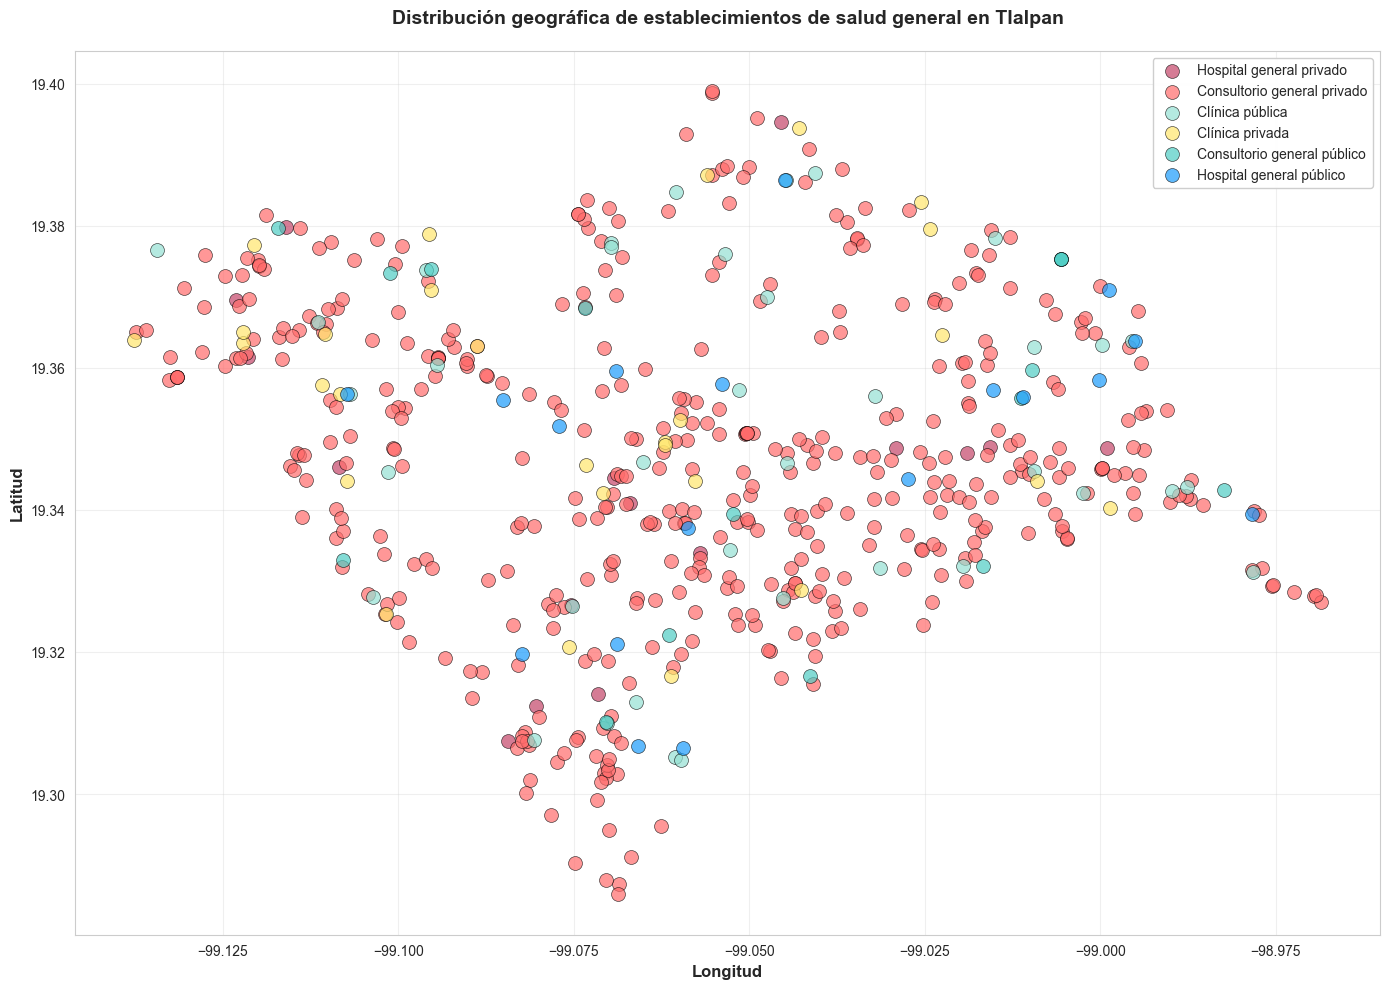

  Generando gráfica 7: Mapa público vs privado...
    ✓ Guardada: outputs/figures/07_mapa_publico_privado.png


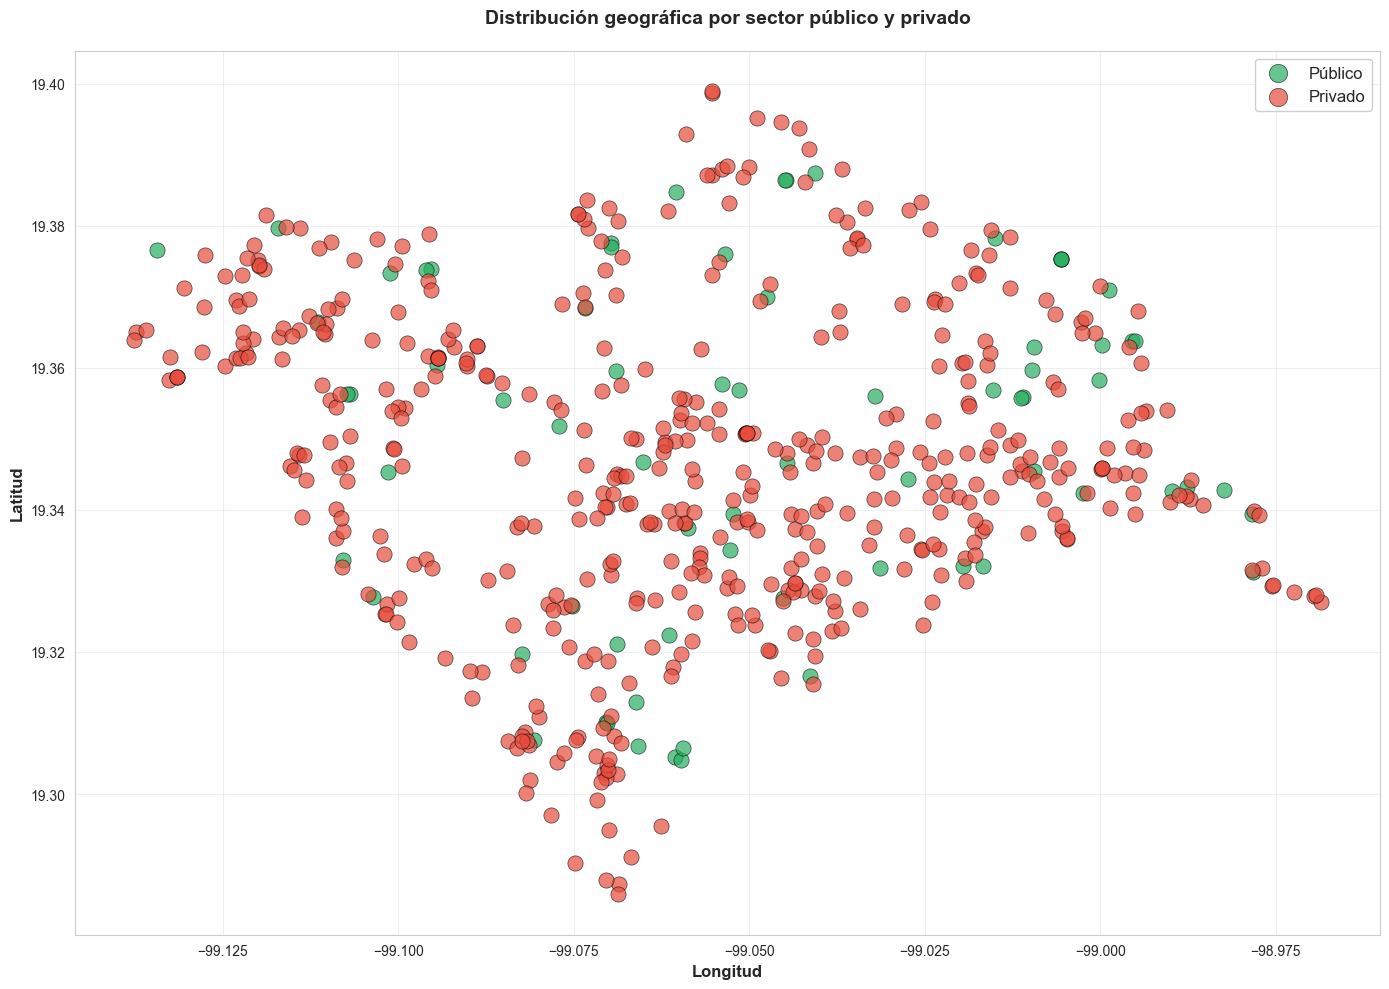

  Generando gráfica 8: Mapa con tamaño operativo...
    ✓ Guardada: outputs/figures/08_mapa_tamano_operativo.png


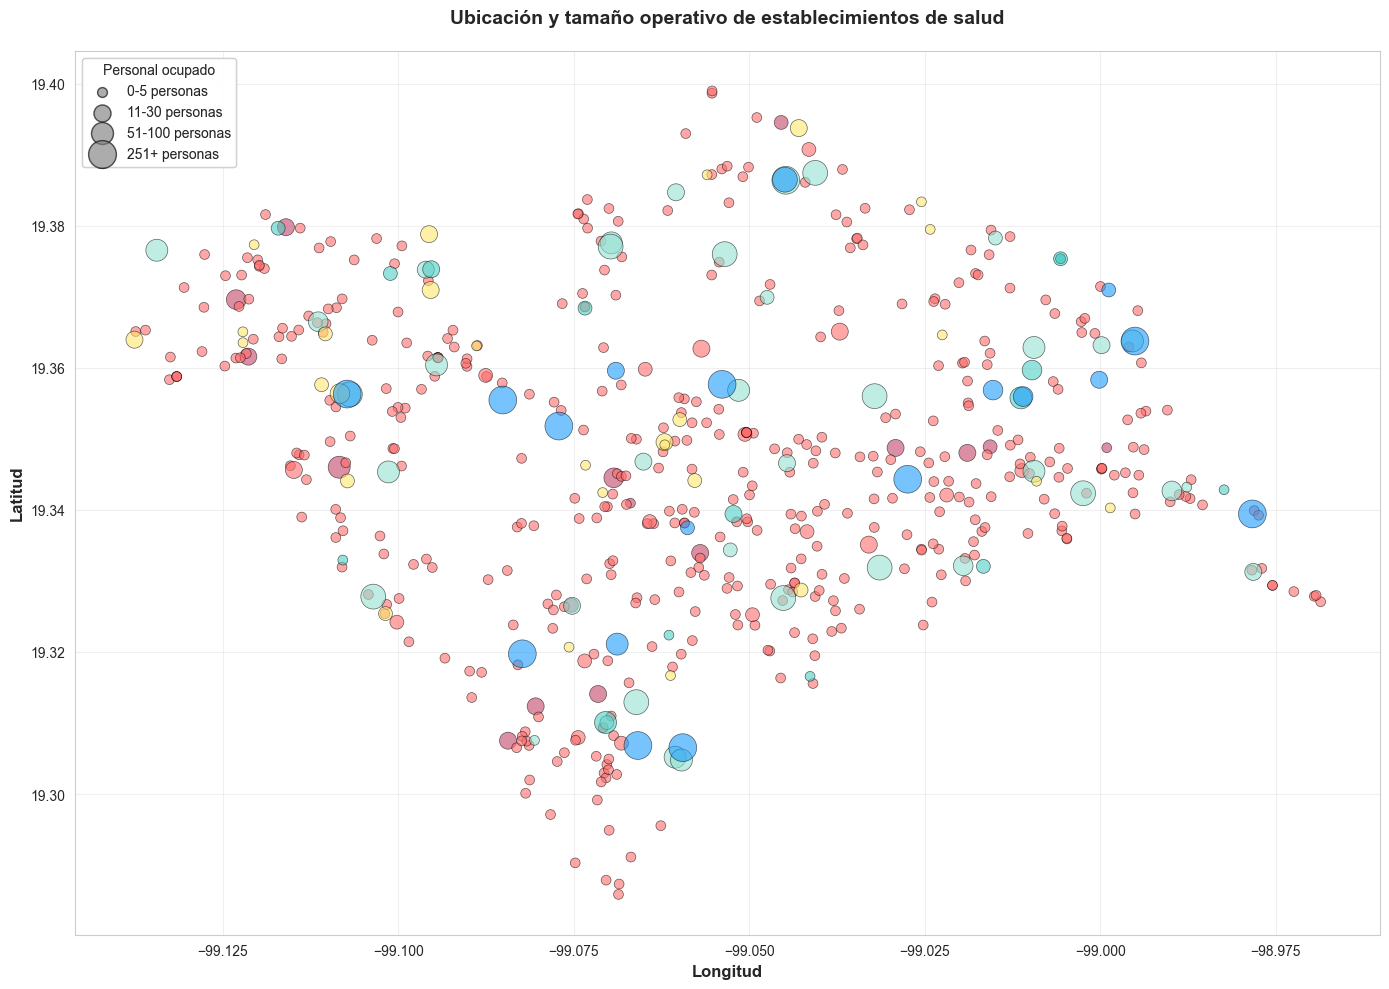

✓ Visualizaciones espaciales completadas


In [8]:
# ============================================================================
# 6. VISUALIZACIONES ESPACIALES
# ============================================================================
print("\n" + "=" * 70)
print("PASO 6: VISUALIZACIONES ESPACIALES")
print("=" * 70)

# Definir paleta de colores para tipo de establecimiento
color_map_tipo = {
    'Consultorio general privado': '#FF6B6B',
    'Consultorio general público': '#4ECDC4',
    'Clínica privada': '#FFE66D',
    'Clínica pública': '#95E1D3',
    'Hospital general privado': '#C44569',
    'Hospital general público': '#1B9CFC'
}

# Definir paleta de colores para sector
color_map_sector = {
    'Privado': '#E74C3C',
    'Público': '#27AE60'
}

# ============ GRÁFICA 6: Mapa de puntos por tipo de establecimiento ============
print("\n  Generando gráfica 6: Mapa de puntos por tipo...")
fig, ax = plt.subplots(figsize=(14, 10))

for tipo in df['tipo_establecimiento'].unique():
    mask = df['tipo_establecimiento'] == tipo
    ax.scatter(df[mask]['longitud'], df[mask]['latitud'], 
              label=tipo, alpha=0.7, s=100, 
              color=color_map_tipo.get(tipo, '#999999'),
              edgecolors='black', linewidth=0.5)

ax.set_title('Distribución geográfica de establecimientos de salud general en Tlalpan', 
             fontsize=14, fontweight='bold', pad=20)
ax.set_xlabel('Longitud', fontsize=12, fontweight='bold')
ax.set_ylabel('Latitud', fontsize=12, fontweight='bold')
ax.legend(loc='best', fontsize=10, framealpha=0.95)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(figures_dir / '06_mapa_puntos_por_tipo.png', dpi=300, bbox_inches='tight')
print(f"    ✓ Guardada: outputs/figures/06_mapa_puntos_por_tipo.png")
plt.show()
plt.close()

# ============ GRÁFICA 7: Mapa sector público vs privado ============
print("  Generando gráfica 7: Mapa público vs privado...")
fig, ax = plt.subplots(figsize=(14, 10))

for sector in ['Público', 'Privado']:
    mask = df['sector'] == sector
    ax.scatter(df[mask]['longitud'], df[mask]['latitud'], 
              label=sector, alpha=0.7, s=120,
              color=color_map_sector[sector],
              edgecolors='black', linewidth=0.5, marker='o')

ax.set_title('Distribución geográfica por sector público y privado', 
             fontsize=14, fontweight='bold', pad=20)
ax.set_xlabel('Longitud', fontsize=12, fontweight='bold')
ax.set_ylabel('Latitud', fontsize=12, fontweight='bold')
ax.legend(loc='best', fontsize=12, framealpha=0.95, markerscale=1.2)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(figures_dir / '07_mapa_publico_privado.png', dpi=300, bbox_inches='tight')
print(f"    ✓ Guardada: outputs/figures/07_mapa_publico_privado.png")
plt.show()
plt.close()

# ============ GRÁFICA 8: Mapa con tamaño operativo ============
print("  Generando gráfica 8: Mapa con tamaño operativo...")
fig, ax = plt.subplots(figsize=(14, 10))

# Mapeo de tamaños según per_ocu
size_map = {
    "0 a 5 personas": 50,
    "6 a 10 personas": 100,
    "11 a 30 personas": 150,
    "31 a 50 personas": 200,
    "51 a 100 personas": 250,
    "101 a 250 personas": 320,
    "251 y más personas": 400
}

# Crear serie de tamaños
tamaños = df['per_ocu'].map(size_map).fillna(50)

for tipo in df['tipo_establecimiento'].unique():
    mask = df['tipo_establecimiento'] == tipo
    ax.scatter(df[mask]['longitud'], df[mask]['latitud'], 
              label=tipo, alpha=0.6, s=tamaños[mask],
              color=color_map_tipo.get(tipo, '#999999'),
              edgecolors='black', linewidth=0.5)

ax.set_title('Ubicación y tamaño operativo de establecimientos de salud', 
             fontsize=14, fontweight='bold', pad=20)
ax.set_xlabel('Longitud', fontsize=12, fontweight='bold')
ax.set_ylabel('Latitud', fontsize=12, fontweight='bold')
ax.legend(loc='best', fontsize=10, framealpha=0.95)
ax.grid(True, alpha=0.3)

# Agregar leyenda de tamaños
legend_sizes = [50, 150, 250, 400]
legend_labels = ["0-5 personas", "11-30 personas", "51-100 personas", "251+ personas"]
legend_handles = [plt.scatter([], [], s=size, c='gray', alpha=0.6, edgecolors='black') 
                 for size in legend_sizes]
legend2 = ax.legend(legend_handles, legend_labels, 
                   scatterpoints=1, loc='upper left', 
                   title='Personal ocupado', fontsize=10)
ax.add_artist(ax.get_legend())

plt.tight_layout()
plt.savefig(figures_dir / '08_mapa_tamano_operativo.png', dpi=300, bbox_inches='tight')
print(f"    ✓ Guardada: outputs/figures/08_mapa_tamano_operativo.png")
plt.show()
plt.close()

print("✓ Visualizaciones espaciales completadas")



PASO 7: CÁLCULO DE DISTANCIA AL VECINO MÁS CERCANO
✓ Distancias calculadas usando BallTree con métrica haversine
  Distancia mínima: 0.00 metros
  Distancia máxima: 751.36 metros
  Distancia promedio: 181.67 metros
  Distancia mediana: 161.71 metros

  Generando gráfica 9: Histograma de distancias...
    ✓ Guardada: outputs/figures/09_hist_distancia_vecino_mas_cercano.png


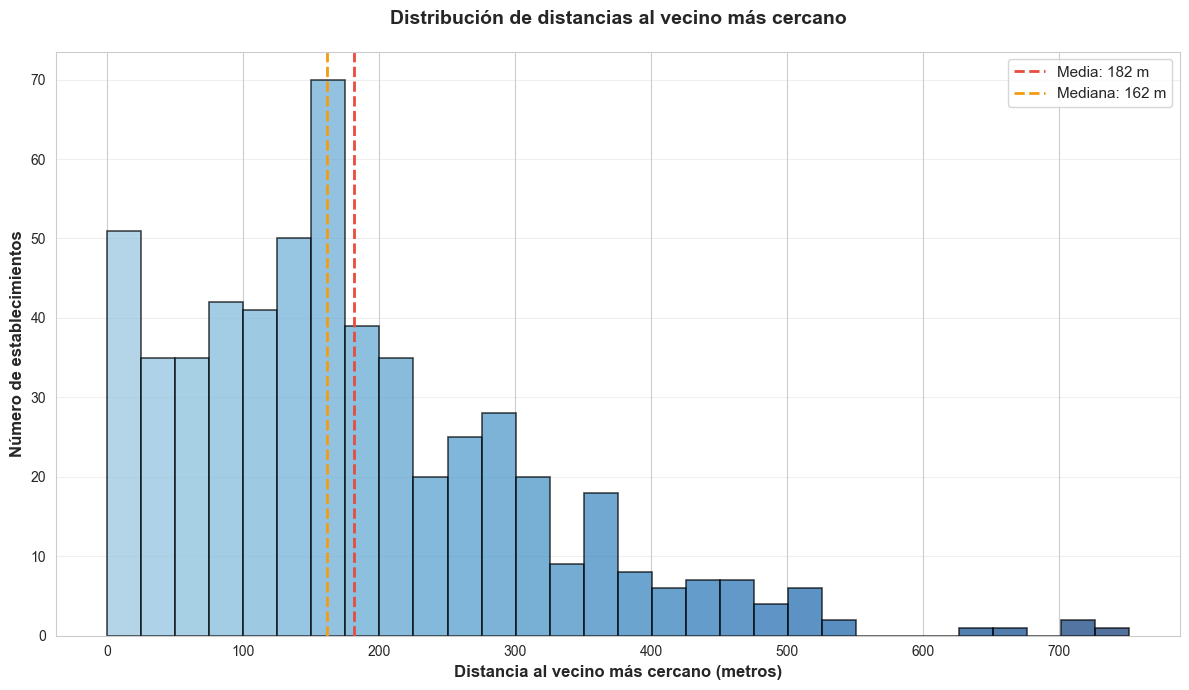

✓ Cálculo de distancias completado


In [9]:
# ============================================================================
# 7. CÁLCULO DE DISTANCIA AL VECINO MÁS CERCANO
# ============================================================================
print("\n" + "=" * 70)
print("PASO 7: CÁLCULO DE DISTANCIA AL VECINO MÁS CERCANO")
print("=" * 70)

# Función de distancia haversine (en metros)
def haversine_distance(lat1, lon1, lat2, lon2):
    """
    Calcula la distancia haversine entre dos puntos en la Tierra (en metros)
    """
    from math import radians, sin, cos, sqrt, atan2
    
    R = 6371000  # Radio de la Tierra en metros
    
    lat1_rad = radians(lat1)
    lon1_rad = radians(lon1)
    lat2_rad = radians(lat2)
    lon2_rad = radians(lon2)
    
    delta_lat = lat2_rad - lat1_rad
    delta_lon = lon2_rad - lon1_rad
    
    a = sin(delta_lat/2)**2 + cos(lat1_rad) * cos(lat2_rad) * sin(delta_lon/2)**2
    c = 2 * atan2(sqrt(a), sqrt(1-a))
    
    return R * c

# Convertir coordenadas a radianes para BallTree
coords_rad = np.radians(df[['latitud', 'longitud']].values)

# Crear BallTree con métrica haversine
tree = BallTree(coords_rad, metric='haversine')

# Encontrar el vecino más cercano (k=2 porque el primero es el mismo punto)
distances, indices = tree.query(coords_rad, k=2)

# Tomar la distancia al segundo vecino más cercano (el primero es distancia 0)
# Convertir de radianes a metros (radio de la Tierra = 6371 km)
distancias_m = distances[:, 1] * 6371000

# Agregar la columna al dataframe
df['distancia_vecino_mas_cercano_m'] = distancias_m

print(f"✓ Distancias calculadas usando BallTree con métrica haversine")
print(f"  Distancia mínima: {distancias_m.min():.2f} metros")
print(f"  Distancia máxima: {distancias_m.max():.2f} metros")
print(f"  Distancia promedio: {distancias_m.mean():.2f} metros")
print(f"  Distancia mediana: {np.median(distancias_m):.2f} metros")

# ============ GRÁFICA 9: Histograma de distancias ============
print("\n  Generando gráfica 9: Histograma de distancias...")
fig, ax = plt.subplots(figsize=(12, 7))

# Crear histograma
n, bins, patches = ax.hist(distancias_m, bins=30, color='#3498db', 
                           edgecolor='black', linewidth=1.2, alpha=0.7)

# Colorear barras con gradiente
cm = plt.cm.Blues
for i, patch in enumerate(patches):
    patch.set_facecolor(cm(0.4 + 0.6 * i / len(patches)))

# Agregar línea de media y mediana
media = distancias_m.mean()
mediana = np.median(distancias_m)
ax.axvline(media, color='#e74c3c', linestyle='--', linewidth=2, label=f'Media: {media:.0f} m')
ax.axvline(mediana, color='#f39c12', linestyle='--', linewidth=2, label=f'Mediana: {mediana:.0f} m')

ax.set_title('Distribución de distancias al vecino más cercano', 
             fontsize=14, fontweight='bold', pad=20)
ax.set_xlabel('Distancia al vecino más cercano (metros)', fontsize=12, fontweight='bold')
ax.set_ylabel('Número de establecimientos', fontsize=12, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig(figures_dir / '09_hist_distancia_vecino_mas_cercano.png', dpi=300, bbox_inches='tight')
print(f"    ✓ Guardada: outputs/figures/09_hist_distancia_vecino_mas_cercano.png")
plt.show()
plt.close()

print("✓ Cálculo de distancias completado")



PASO 8: IDENTIFICACIÓN DE ESTABLECIMIENTOS AISLADOS
✓ Percentil 90 de distancias: 359.17 metros
  Establecimientos aislados: 57
  Porcentaje: 10.12%

  Generando gráfica 10: Mapa de establecimientos aislados...
    ✓ Guardada: outputs/figures/10_mapa_establecimientos_aislados.png


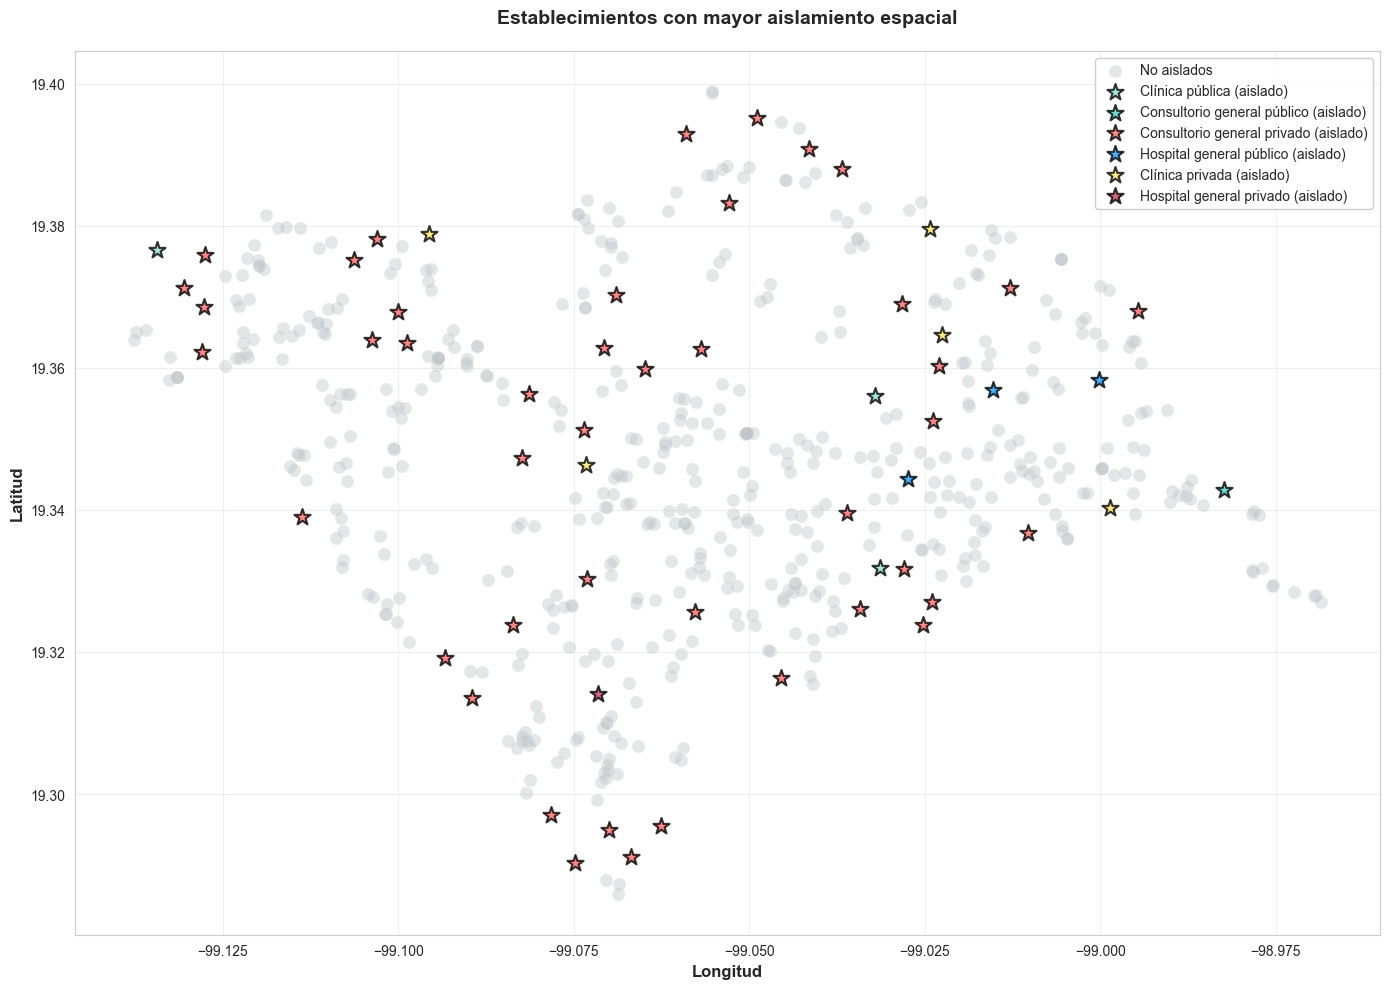

✓ Análisis de aislamiento completado


In [10]:
# ============================================================================
# 8. IDENTIFICACIÓN DE ESTABLECIMIENTOS AISLADOS
# ============================================================================
print("\n" + "=" * 70)
print("PASO 8: IDENTIFICACIÓN DE ESTABLECIMIENTOS AISLADOS")
print("=" * 70)

# Calcular percentil 90
percentil_90 = np.percentile(distancias_m, 90)
df['es_aislado'] = distancias_m > percentil_90

print(f"✓ Percentil 90 de distancias: {percentil_90:.2f} metros")
print(f"  Establecimientos aislados: {df['es_aislado'].sum()}")
print(f"  Porcentaje: {(df['es_aislado'].sum() / len(df) * 100):.2f}%")

# ============ GRÁFICA 10: Mapa de establecimientos aislados ============
print("\n  Generando gráfica 10: Mapa de establecimientos aislados...")
fig, ax = plt.subplots(figsize=(14, 10))

# Puntos no aislados (gris claro)
no_aislados = df[~df['es_aislado']]
ax.scatter(no_aislados['longitud'], no_aislados['latitud'], 
          label='No aislados', alpha=0.4, s=80,
          color='#bdc3c7', edgecolors='lightgray', linewidth=0.3)

# Puntos aislados (coloreados por tipo)
aislados = df[df['es_aislado']]
for tipo in aislados['tipo_establecimiento'].unique():
    mask = (df['tipo_establecimiento'] == tipo) & (df['es_aislado'])
    ax.scatter(df[mask]['longitud'], df[mask]['latitud'], 
              label=f'{tipo} (aislado)', alpha=0.8, s=150,
              color=color_map_tipo.get(tipo, '#999999'),
              edgecolors='black', linewidth=1.5, marker='*')

ax.set_title('Establecimientos con mayor aislamiento espacial', 
             fontsize=14, fontweight='bold', pad=20)
ax.set_xlabel('Longitud', fontsize=12, fontweight='bold')
ax.set_ylabel('Latitud', fontsize=12, fontweight='bold')
ax.legend(loc='best', fontsize=10, framealpha=0.95)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(figures_dir / '10_mapa_establecimientos_aislados.png', dpi=300, bbox_inches='tight')
print(f"    ✓ Guardada: outputs/figures/10_mapa_establecimientos_aislados.png")
plt.show()
plt.close()

print("✓ Análisis de aislamiento completado")


In [11]:
# ============================================================================
# 9. EXPORTACIÓN DE RESULTADOS
# ============================================================================
print("\n" + "=" * 70)
print("PASO 9: EXPORTACIÓN DE RESULTADOS")
print("=" * 70)

# Exportar base de datos enriquecida
output_csv = output_dir / 'salud_general_iztapalapa_enriquecida.csv'
df.to_csv(output_csv, index=False, encoding='latin1')
print(f"\n✓ Base de datos enriquecida exportada")
print(f"  Archivo: outputs/salud_general_iztapalapa_enriquecida.csv")
print(f"  Columnas: {list(df.columns)}")
print(f"  Registros: {len(df)}")



PASO 9: EXPORTACIÓN DE RESULTADOS

✓ Base de datos enriquecida exportada
  Archivo: outputs/salud_general_iztapalapa_enriquecida.csv
  Columnas: ['id', 'clee', 'nom_estab', 'raz_social', 'codigo_act', 'nombre_act', 'per_ocu', 'tipo_vial', 'nom_vial', 'tipo_v_e_1', 'nom_v_e_1', 'tipo_v_e_2', 'nom_v_e_2', 'tipo_v_e_3', 'nom_v_e_3', 'numero_ext', 'letra_ext', 'edificio', 'edificio_e', 'numero_int', 'letra_int', 'tipo_asent', 'nomb_asent', 'tipoCenCom', 'nom_CenCom', 'num_local', 'cod_postal', 'cve_ent', 'entidad', 'cve_mun', 'municipio', 'cve_loc', 'localidad', 'ageb', 'manzana', 'telefono', 'correoelec', 'www', 'tipoUniEco', 'latitud', 'longitud', 'fecha_alta', 'sector', 'tipo_establecimiento', 'distancia_vecino_mas_cercano_m', 'es_aislado']
  Registros: 563


In [12]:
# ============================================================================
# 10. RESUMEN FINAL DEL ANÁLISIS
# ============================================================================
print("\n" + "=" * 70)
print("RESUMEN FINAL DEL ANÁLISIS")
print("=" * 70)

print(f"\n{'ESTABLECIMIENTO Y DISTRIBUCIÓN':^70}")
print("-" * 70)
print(f"Total de establecimientos: {len(df)}")

print(f"\n{'Conteo por tipo de establecimiento:':^70}")
conteo_tipo_resumen = df['tipo_establecimiento'].value_counts().sort_values(ascending=False)
for tipo, count in conteo_tipo_resumen.items():
    pct = (count / len(df)) * 100
    print(f"  {tipo}: {count:>3d} ({pct:>5.1f}%)")

print(f"\n{'Conteo por sector:':^70}")
conteo_sector_resumen = df['sector'].value_counts()
for sector, count in conteo_sector_resumen.items():
    pct = (count / len(df)) * 100
    print(f"  {sector}: {count:>3d} ({pct:>5.1f}%)")

print(f"\n{'Distribución por personal ocupado:':^70}")
conteo_per_ocu_resumen = df['per_ocu'].value_counts().sort_index()
for per_ocu, count in conteo_per_ocu_resumen.items():
    pct = (count / len(df)) * 100
    print(f"  {per_ocu}: {count:>3d} ({pct:>5.1f}%)")

print(f"\n{'Top 10 códigos postales:':^70}")
top10_resumen = df['cod_postal'].value_counts().head(10)
for i, (codigo, count) in enumerate(top10_resumen.items(), 1):
    pct = (count / len(df)) * 100
    print(f"  {i:2d}. {codigo}: {count:>3d} ({pct:>5.1f}%)")

print(f"\n{'ANÁLISIS ESPACIAL':^70}")
print("-" * 70)
print(f"Distancia promedio al vecino más cercano: {distancias_m.mean():.2f} metros")
print(f"Distancia mediana al vecino más cercano: {np.median(distancias_m):.2f} metros")
print(f"Distancia mínima: {distancias_m.min():.2f} metros")
print(f"Distancia máxima: {distancias_m.max():.2f} metros")
print(f"Desv. Est. de distancias: {distancias_m.std():.2f} metros")
print(f"\nEstablecimientos aislados (percentil 90): {df['es_aislado'].sum()}")
print(f"Distancia umbral para aislamiento: {percentil_90:.2f} metros")

print(f"\n{'ARCHIVOS GENERADOS':^70}")
print("-" * 70)
print("Visualizaciones descriptivas:")
print("  ✓ 01_barras_tipo_establecimiento.png")
print("  ✓ 02_barras_sector.png")
print("  ✓ 03_barras_personal_ocupado.png")
print("  ✓ 04_personal_ocupado_por_tipo.png")
print("  ✓ 05_top10_codigos_postales.png")

print("\nVisualizaciones espaciales:")
print("  ✓ 06_mapa_puntos_por_tipo.png")
print("  ✓ 07_mapa_publico_privado.png")
print("  ✓ 08_mapa_tamano_operativo.png")

print("\nAnálisis de aislamiento:")
print("  ✓ 09_hist_distancia_vecino_mas_cercano.png")
print("  ✓ 10_mapa_establecimientos_aislados.png")

print("\nDatos enriquecidos:")
print("  ✓ salud_general_tlalpan_enriquecida.csv")

print(f"\n{'ANÁLISIS COMPLETADO EXITOSAMENTE':^70}")
print("=" * 70)
print("\nNota: Los datos están listos para persistencia homológica.")
print("      Las visualizaciones están en la carpeta 'outputs/figures'")



RESUMEN FINAL DEL ANÁLISIS

                    ESTABLECIMIENTO Y DISTRIBUCIÓN                    
----------------------------------------------------------------------
Total de establecimientos: 563

                 Conteo por tipo de establecimiento:                  
  Consultorio general privado: 448 ( 79.6%)
  Clínica pública:  37 (  6.6%)
  Clínica privada:  28 (  5.0%)
  Hospital general público:  18 (  3.2%)
  Hospital general privado:  16 (  2.8%)
  Consultorio general público:  16 (  2.8%)

                          Conteo por sector:                          
  Privado: 492 ( 87.4%)
  Público:  71 ( 12.6%)

                  Distribución por personal ocupado:                  
  0 a 5 personas: 456 ( 81.0%)
  6 a 10 personas:  34 (  6.0%)
  11 a 30 personas:  28 (  5.0%)
  31 a 50 personas:   9 (  1.6%)
  51 a 100 personas:  14 (  2.5%)
  101 a 250 personas:  11 (  2.0%)
  251 y más personas:  11 (  2.0%)

                       Top 10 códigos postales:                   

In [13]:
import geopandas as gpd

alcaldias = gpd.read_file("data/limite-de-las-alcaldas.json")

print(alcaldias.columns)
print(alcaldias["NOMGEO"].unique())

tlalpan = alcaldias[alcaldias["NOMGEO"] == "Iztapalapa"]

ModuleNotFoundError: No module named 'geopandas'

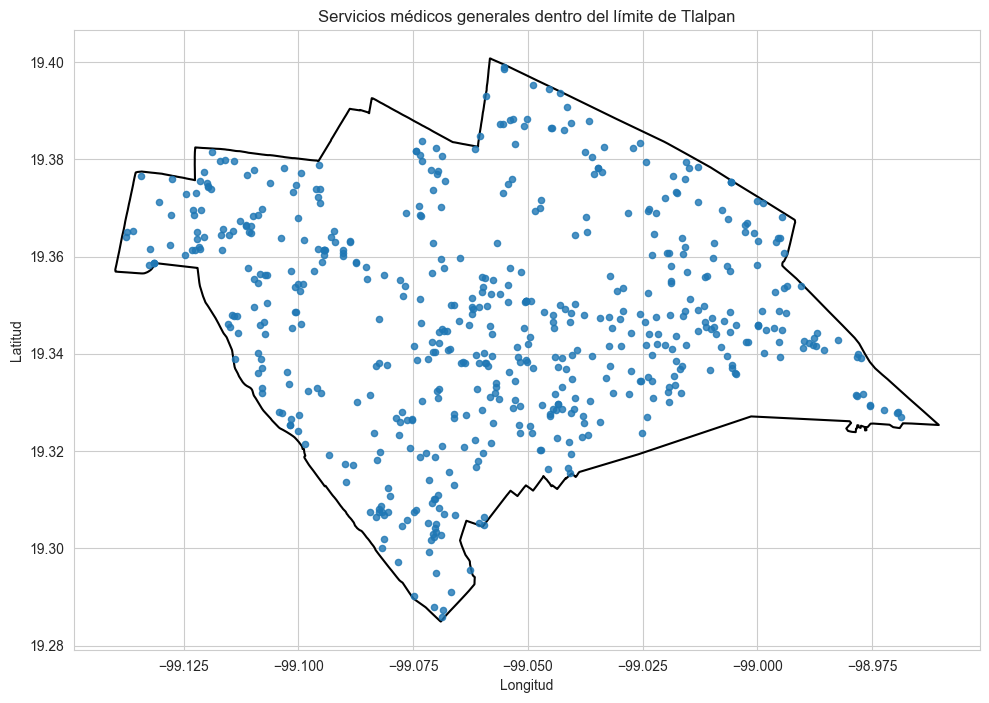

In [ ]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt

# Cargar puntos
df = pd.read_csv("outputs/salud_general_iztapalapa_enriquecida.csv", encoding="latin1")

# Convertir puntos a GeoDataFrame
gdf_puntos = gpd.GeoDataFrame(
    df,
    geometry=gpd.points_from_xy(df["longitud"], df["latitud"]),
    crs="EPSG:4326"
)

# Cargar alcaldías
alcaldias = gpd.read_file("data/limite-de-las-alcaldas.json")

# Filtrar Tlalpan
tlalpan = alcaldias[alcaldias["NOMGEO"] == "Iztapalapa"]

# Graficar
fig, ax = plt.subplots(figsize=(10, 10))

tlalpan.plot(
    ax=ax,
    facecolor="none",
    edgecolor="black",
    linewidth=1.5
)

gdf_puntos.plot(
    ax=ax,
    markersize=20,
    alpha=0.8
)

ax.set_title("Servicios médicos generales dentro del límite de Tlalpan")
ax.set_xlabel("Longitud")
ax.set_ylabel("Latitud")

plt.tight_layout()
plt.show()


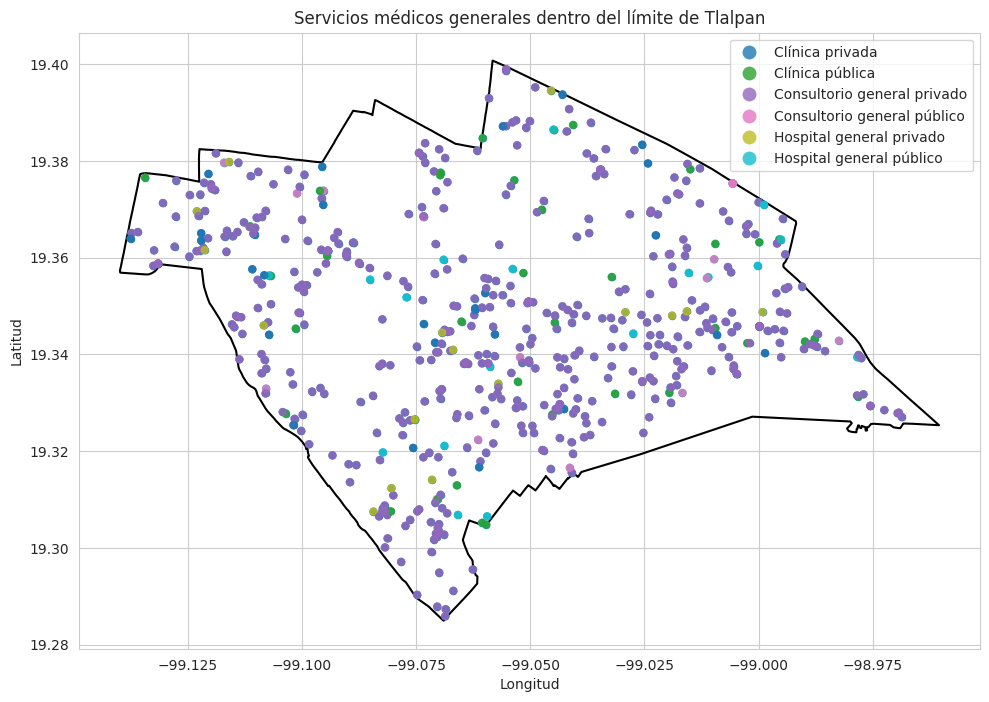

In [ ]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt

# Cargar puntos
df = pd.read_csv("outputs/salud_general_iztapalapa_enriquecida.csv", encoding="latin1")

# Convertir puntos a GeoDataFrame
gdf_puntos = gpd.GeoDataFrame(
    df,
    geometry=gpd.points_from_xy(df["longitud"], df["latitud"]),
    crs="EPSG:4326"
)

# Cargar alcaldías
alcaldias = gpd.read_file("data/limite-de-las-alcaldas.json")

# Filtrar Tlalpan
tlalpan = alcaldias[alcaldias["NOMGEO"] == "Iztapalapa"]

# Graficar
fig, ax = plt.subplots(figsize=(10, 10))

tlalpan.plot(
    ax=ax,
    facecolor="none",
    edgecolor="black",
    linewidth=1.5
)

gdf_puntos.plot(
    ax=ax,
    markersize=20,
    alpha=0.8
)
gdf_puntos.plot(
    ax=ax,
    column="sector",
    legend=True,
    markersize=25,
    alpha=0.8
)
gdf_puntos.plot(
    ax=ax,
    column="tipo_establecimiento",
    legend=True,
    markersize=25,
    alpha=0.8
)

ax.set_title("Servicios médicos generales dentro del límite de Tlalpan")
ax.set_xlabel("Longitud")
ax.set_ylabel("Latitud")

plt.tight_layout()
plt.show()

Número de puntos usados: 563


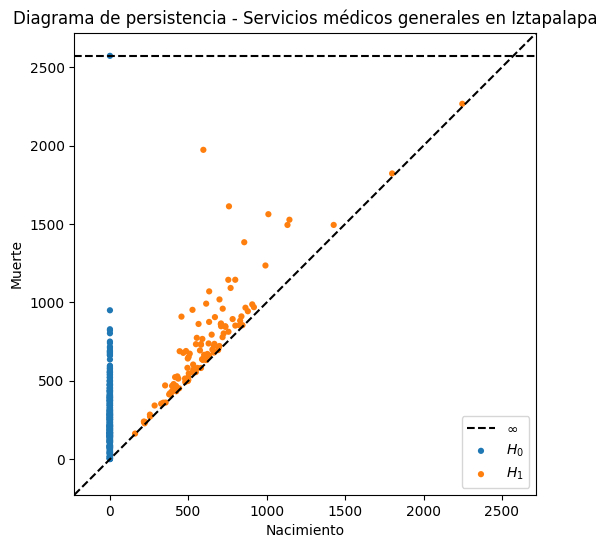

In [ ]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
from ripser import ripser
from persim import plot_diagrams

# =========================
# 1. Cargar base de Iztapalapa
# =========================

df = pd.read_csv(
    "outputs/salud_general_iztapalapa_enriquecida.csv",
    encoding="latin1"
)

# Asegurar coordenadas numéricas
df["latitud"] = pd.to_numeric(df["latitud"], errors="coerce")
df["longitud"] = pd.to_numeric(df["longitud"], errors="coerce")

# Eliminar puntos sin coordenadas
df = df.dropna(subset=["latitud", "longitud"]).copy()

# =========================
# 2. Convertir a GeoDataFrame
# =========================

gdf_puntos = gpd.GeoDataFrame(
    df,
    geometry=gpd.points_from_xy(df["longitud"], df["latitud"]),
    crs="EPSG:4326"
)

# =========================
# 3. Proyectar a metros
# =========================

gdf_metros = gdf_puntos.to_crs("EPSG:32614")

gdf_metros["x_m"] = gdf_metros.geometry.x
gdf_metros["y_m"] = gdf_metros.geometry.y

coordinates = gdf_metros[["x_m", "y_m"]].values

# Centrar coordenadas
coordinates = coordinates - coordinates.mean(axis=0)

print("Número de puntos usados:", coordinates.shape[0])

# =========================
# 4. Persistencia homológica
# =========================

result = ripser(
    coordinates,
    maxdim=1,
    thresh=5000
)

diagrams = result["dgms"]

# =========================
# 5. Diagrama de persistencia
# =========================

plt.figure(figsize=(8, 6))

plot_diagrams(
    diagrams,
    show=False,
    labels=[r"$H_0$", r"$H_1$"]
)

plt.title("Diagrama de persistencia - Servicios médicos generales en Iztapalapa")
plt.xlabel("Nacimiento")
plt.ylabel("Muerte")

plt.savefig(
    "outputs/figures/diagrama_persistencia_iztapalapa_metros.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

En tu contexto, eso podría interpretarse así:

Existen regiones donde los establecimientos médicos forman una estructura alrededor de zonas con menor presencia interna de servicios. Estos ciclos persistentes pueden sugerir vacíos relativos de cobertura, aunque deben interpretarse junto con el mapa territorial y la distribución urbana.

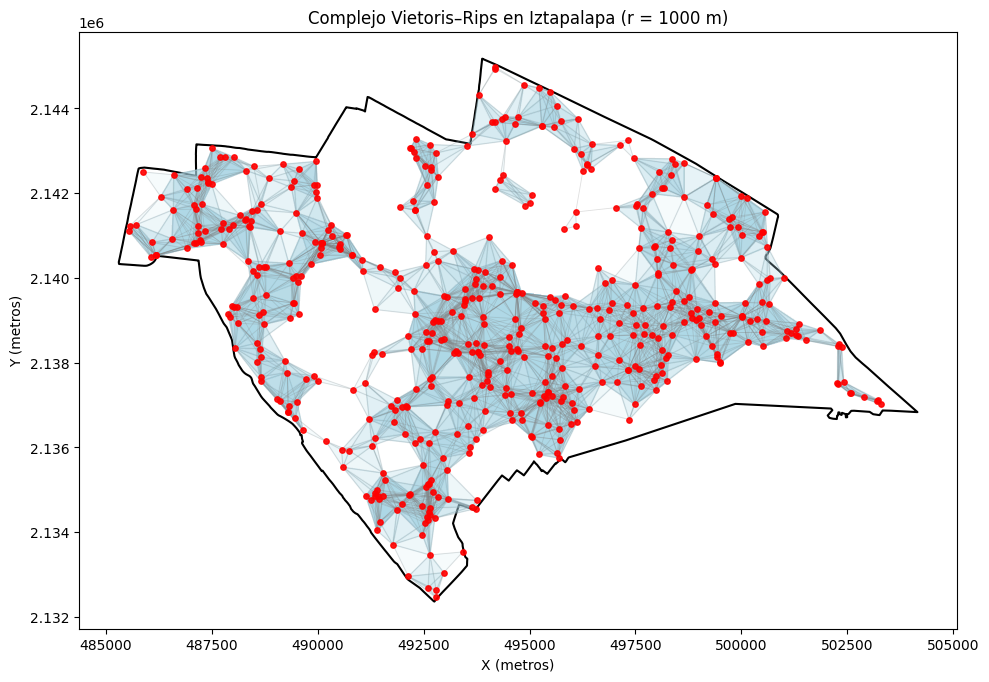

In [ ]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
from itertools import combinations
from scipy.spatial.distance import pdist, squareform

# =========================================
# 1. Cargar datos de Iztapalapa
# =========================================

df = pd.read_csv(
    "outputs/salud_general_iztapalapa_enriquecida.csv",
    encoding="latin1"
)

df["latitud"] = pd.to_numeric(df["latitud"], errors="coerce")
df["longitud"] = pd.to_numeric(df["longitud"], errors="coerce")
df = df.dropna(subset=["latitud", "longitud"]).copy()

# GeoDataFrame de puntos
gdf = gpd.GeoDataFrame(
    df,
    geometry=gpd.points_from_xy(df["longitud"], df["latitud"]),
    crs="EPSG:4326"
)

# =========================================
# 2. Cargar límite de alcaldías y filtrar Iztapalapa
# =========================================

alcaldias = gpd.read_file("data/limite-de-las-alcaldas.json").to_crs("EPSG:4326")
iztapalapa = alcaldias[alcaldias["NOMGEO"] == "Iztapalapa"]

# =========================================
# 3. Proyectar a metros
# =========================================

gdf_m = gdf.to_crs("EPSG:32614")
iztapalapa_m = iztapalapa.to_crs("EPSG:32614")

coords = np.array([(geom.x, geom.y) for geom in gdf_m.geometry])

# Matriz de distancias
D = squareform(pdist(coords))

# =========================================
# 4. Elegir radio del complejo
# =========================================

radio = 1000  # metros

# =========================================
# 5. Graficar complejo Vietoris-Rips
# =========================================

fig, ax = plt.subplots(figsize=(10, 10))

# Límite de Iztapalapa
iztapalapa_m.plot(
    ax=ax,
    facecolor="none",
    edgecolor="black",
    linewidth=1.5
)

# -----------------------------------------
# 5A. Dibujar triángulos (opcional)
# -----------------------------------------
# OJO: si hay demasiados puntos, esto puede saturar mucho la imagen.
# Si se ve demasiado cargado, comenta esta sección.

for i, j, k in combinations(range(len(coords)), 3):
    if D[i, j] <= radio and D[i, k] <= radio and D[j, k] <= radio:
        triangle = np.array([coords[i], coords[j], coords[k]])
        ax.fill(
            triangle[:, 0],
            triangle[:, 1],
            color="lightblue",
            alpha=0.10,
            zorder=1
        )

# -----------------------------------------
# 5B. Dibujar aristas
# -----------------------------------------

for i, j in combinations(range(len(coords)), 2):
    if D[i, j] <= radio:
        x1, y1 = coords[i]
        x2, y2 = coords[j]
        ax.plot(
            [x1, x2],
            [y1, y2],
            color="gray",
            alpha=0.25,
            linewidth=0.6,
            zorder=2
        )

# -----------------------------------------
# 5C. Dibujar vértices
# -----------------------------------------

gdf_m.plot(
    ax=ax,
    color="red",
    markersize=15,
    alpha=0.9,
    zorder=3
)

ax.set_title(f"Complejo Vietoris–Rips en Iztapalapa (r = {radio} m)")
ax.set_xlabel("X (metros)")
ax.set_ylabel("Y (metros)")
ax.set_aspect("equal")

plt.tight_layout()
plt.savefig(
    f"outputs/figures/complejo_vietoris_rips_iztapalapa_{radio}m.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

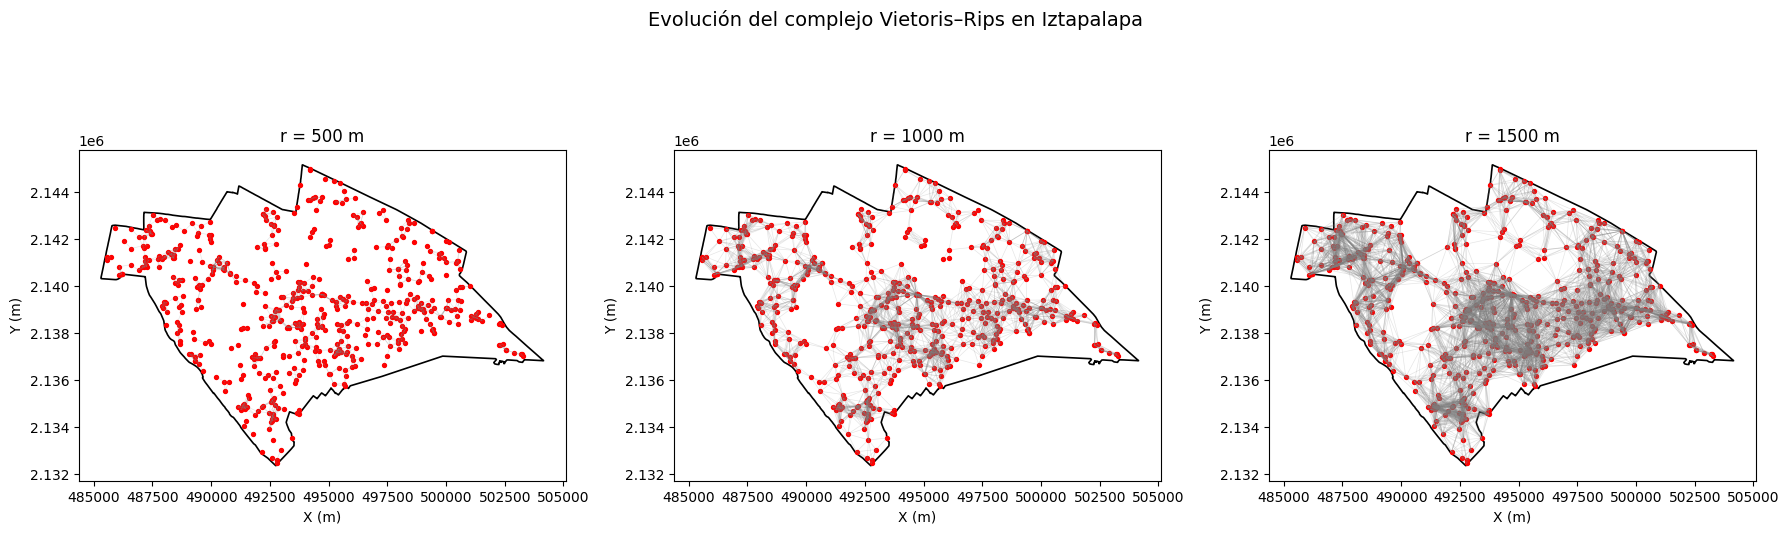

In [ ]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
from itertools import combinations
from scipy.spatial.distance import pdist, squareform

# =========================
# Cargar datos
# =========================

df = pd.read_csv(
    "outputs/salud_general_iztapalapa_enriquecida.csv",
    encoding="latin1"
)

df["latitud"] = pd.to_numeric(df["latitud"], errors="coerce")
df["longitud"] = pd.to_numeric(df["longitud"], errors="coerce")
df = df.dropna(subset=["latitud", "longitud"]).copy()

gdf = gpd.GeoDataFrame(
    df,
    geometry=gpd.points_from_xy(df["longitud"], df["latitud"]),
    crs="EPSG:4326"
)

alcaldias = gpd.read_file("data/limite-de-las-alcaldas.json").to_crs("EPSG:4326")
iztapalapa = alcaldias[alcaldias["NOMGEO"] == "Iztapalapa"]

gdf_m = gdf.to_crs("EPSG:32614")
iztapalapa_m = iztapalapa.to_crs("EPSG:32614")

coords = np.array([(geom.x, geom.y) for geom in gdf_m.geometry])
D = squareform(pdist(coords))

# =========================
# Comparar radios
# =========================

radios = [500, 1000, 1500]

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for ax, radio in zip(axes, radios):
    iztapalapa_m.plot(
        ax=ax,
        facecolor="none",
        edgecolor="black",
        linewidth=1.2
    )

    # Aristas
    for i, j in combinations(range(len(coords)), 2):
        if D[i, j] <= radio:
            x1, y1 = coords[i]
            x2, y2 = coords[j]
            ax.plot(
                [x1, x2],
                [y1, y2],
                color="gray",
                alpha=0.20,
                linewidth=0.5
            )

    # Puntos
    gdf_m.plot(ax=ax, color="red", markersize=8)

    ax.set_title(f"r = {radio} m")
    ax.set_aspect("equal")
    ax.set_xlabel("X (m)")
    ax.set_ylabel("Y (m)")

plt.suptitle("Evolución del complejo Vietoris–Rips en Iztapalapa", fontsize=14)
plt.tight_layout()
plt.savefig(
    "outputs/figures/comparacion_vietoris_rips_iztapalapa.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()